# 1.2 Visuelle Odometrie – Schritt für Schritt

Ziel: Berechne wie sich die Kamera zwischen zwei aufeinanderfolgenden Frames bewegt hat.

**Pipeline:**
```
Frame 1 + Frame 2
    → Schritt 1: Features extrahieren (ORB)
    → Schritt 2: Feature Matching (Fingerabdrücke vergleichen)
    → Schritt 3: Ausreißer entfernen (RANSAC)
    → Schritt 4: Essential Matrix berechnen
    → Schritt 5: Bewegung R und t bestimmen
```

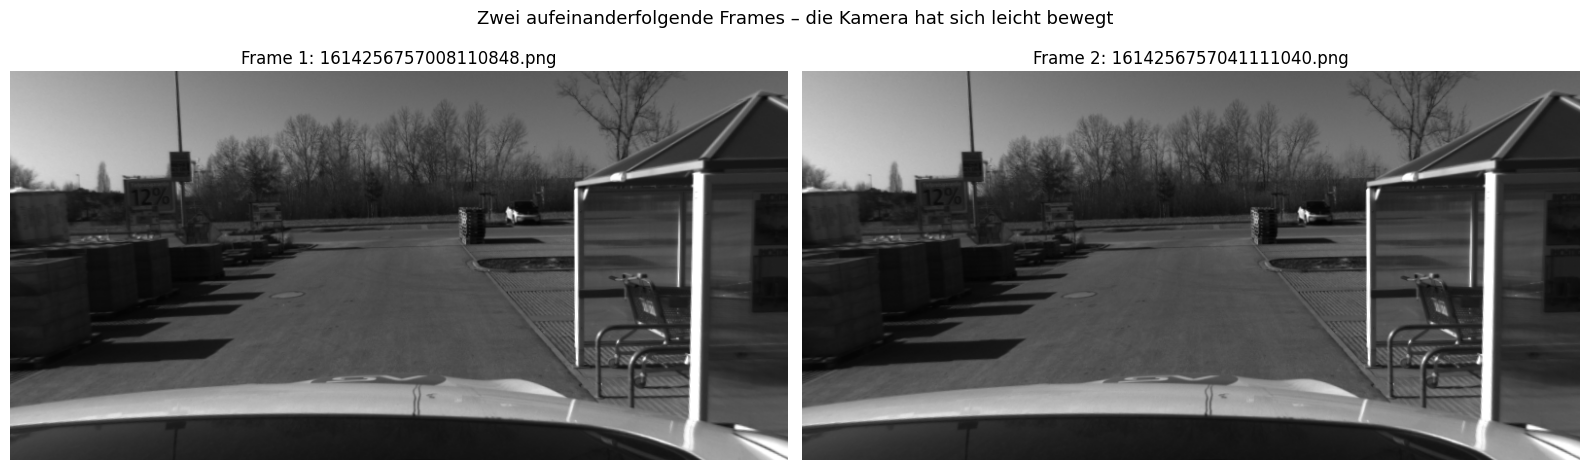

Bildgröße: 800 x 400 Pixel


In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

CAM0_ORDNER = "../cam0"

# Zwei aufeinanderfolgende Frames laden
bilder = sorted(os.listdir(CAM0_ORDNER))

frame1 = cv2.imread(os.path.join(CAM0_ORDNER, bilder[0]))
frame2 = cv2.imread(os.path.join(CAM0_ORDNER, bilder[1]))

frame1_rgb = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
frame2_rgb = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(frame1_rgb)
axes[0].set_title(f"Frame 1: {bilder[0]}")
axes[0].axis('off')
axes[1].imshow(frame2_rgb)
axes[1].set_title(f"Frame 2: {bilder[1]}")
axes[1].axis('off')
plt.suptitle("Zwei aufeinanderfolgende Frames – die Kamera hat sich leicht bewegt", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Bildgröße: {frame1.shape[1]} x {frame1.shape[0]} Pixel")

---
## Schritt 1: Features in beiden Frames extrahieren

Wie in Notebook 1.1 — wir extrahieren ORB Features aus **beiden** Frames.
Diese Features werden im nächsten Schritt miteinander verglichen.

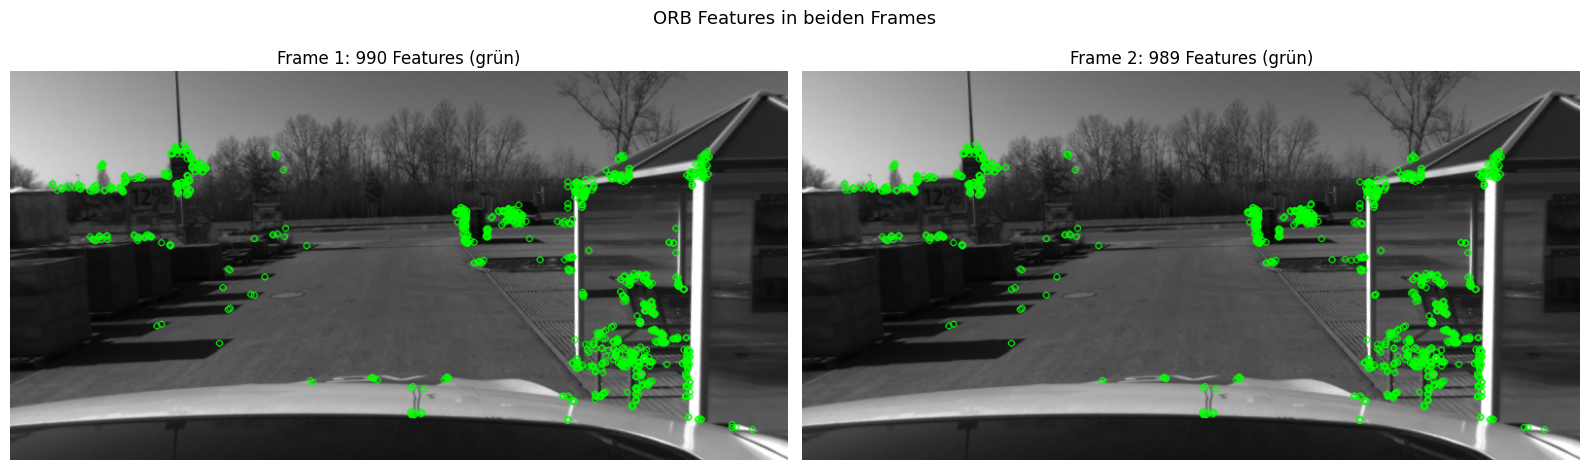

In [26]:
orb = cv2.ORB_create(nfeatures=1000)

grau1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
grau2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

kp1, desc1 = orb.detectAndCompute(grau1, None)
kp2, desc2 = orb.detectAndCompute(grau2, None)

bild1_kp = cv2.drawKeypoints(frame1_rgb, kp1, None, color=(0,255,0))
bild2_kp = cv2.drawKeypoints(frame2_rgb, kp2, None, color=(0,255,0))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(bild1_kp)
axes[0].set_title(f"Frame 1: {len(kp1)} Features (grün)")
axes[0].axis('off')
axes[1].imshow(bild2_kp)
axes[1].set_title(f"Frame 2: {len(kp2)} Features (grün)")
axes[1].axis('off')
plt.suptitle("ORB Features in beiden Frames", fontsize=13)
plt.tight_layout()
plt.show()

---
## Schritt 2: Feature Matching

Für jeden Feature in Frame 1 suchen wir den **ähnlichsten Feature in Frame 2**.
Verglichen werden die 256-bit Descriptors mit der **Hamming-Distanz**:

```
Descriptor 1: 10110101...
Descriptor 2: 10110001...
                   ↑
              1 Bit unterschiedlich → Hamming-Distanz = 1  → sehr guter Match

Descriptor 1: 10110101...
Descriptor 3: 01001010...
              ↑↑↑↑↑↑↑↑
              8 Bits unterschiedlich → Hamming-Distanz = 8  → schlechter Match
```

**Je kleiner die Distanz, desto besser der Match.**

Alle möglichen Matches:  990
Gute Matches (nach Ratio Test): 946
Verworfen: 44


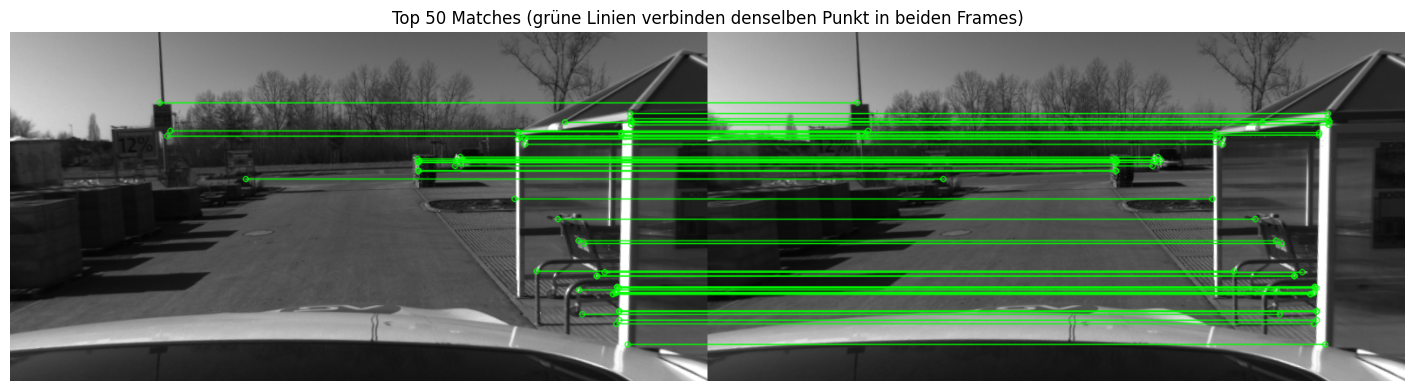

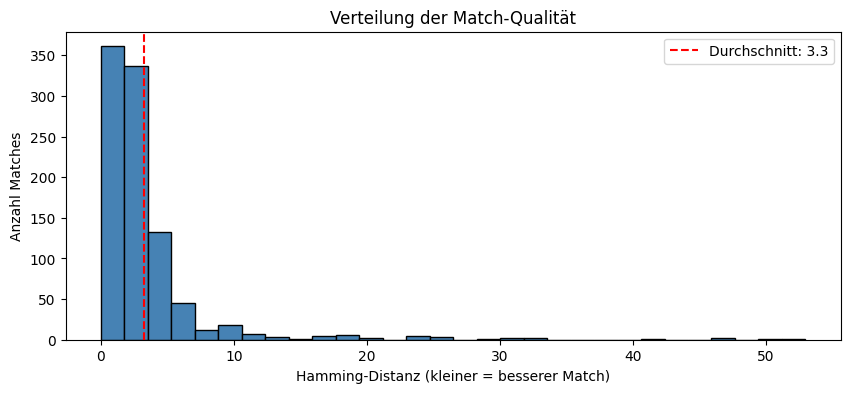

In [27]:
# Brute-Force Matcher mit Hamming-Distanz
matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

# Für jeden Feature die 2 besten Matches finden
alle_matches = matcher.knnMatch(desc1, desc2, k=2)

# Lowe's Ratio Test: nur Matches behalten wo bester Match deutlich besser als zweitbester
gute_matches = []
for m, n in alle_matches:
    if m.distance < 0.75 * n.distance:
        gute_matches.append(m)

print(f"Alle möglichen Matches:  {len(alle_matches)}")
print(f"Gute Matches (nach Ratio Test): {len(gute_matches)}")
print(f"Verworfen: {len(alle_matches) - len(gute_matches)}")

# Top 50 Matches visualisieren (sortiert nach Qualität)
gute_matches_sortiert = sorted(gute_matches, key=lambda x: x.distance)
top_matches = gute_matches_sortiert[:50]

bild_matches = cv2.drawMatches(frame1_rgb, kp1, frame2_rgb, kp2,
                                top_matches, None,
                                matchColor=(0, 255, 0),
                                singlePointColor=(255, 0, 0),
                                flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(18, 6))
plt.imshow(bild_matches)
plt.title(f"Top 50 Matches (grüne Linien verbinden denselben Punkt in beiden Frames)")
plt.axis('off')
plt.show()

# Qualitätsverteilung zeigen
distanzen = [m.distance for m in gute_matches]
plt.figure(figsize=(10, 4))
plt.hist(distanzen, bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Hamming-Distanz (kleiner = besserer Match)')
plt.ylabel('Anzahl Matches')
plt.title('Verteilung der Match-Qualität')
plt.axvline(np.mean(distanzen), color='red', linestyle='--', label=f'Durchschnitt: {np.mean(distanzen):.1f}')
plt.legend()
plt.show()

---
## Schritt 3: Ausreißer entfernen (RANSAC)

Nicht alle Matches sind korrekt — manche Features wurden **falsch zugeordnet**.
RANSAC findet die konsistenten Matches und wirft die falschen raus:

```
Ablauf:
  Wiederhole 1000x:
    → Wähle 8 zufällige Matches
    → Berechne Modell daraus
    → Zähle wie viele andere Matches zu diesem Modell passen (Inlier)
  → Behalte das Modell mit den meisten Inliers
```

Anzahl Punkte für RANSAC: 500
Vor RANSAC:  500 Matches
Inlier:      500  ✓ (korrekte Matches)
Outlier:     0  ✗ (falsche Matches, verworfen)


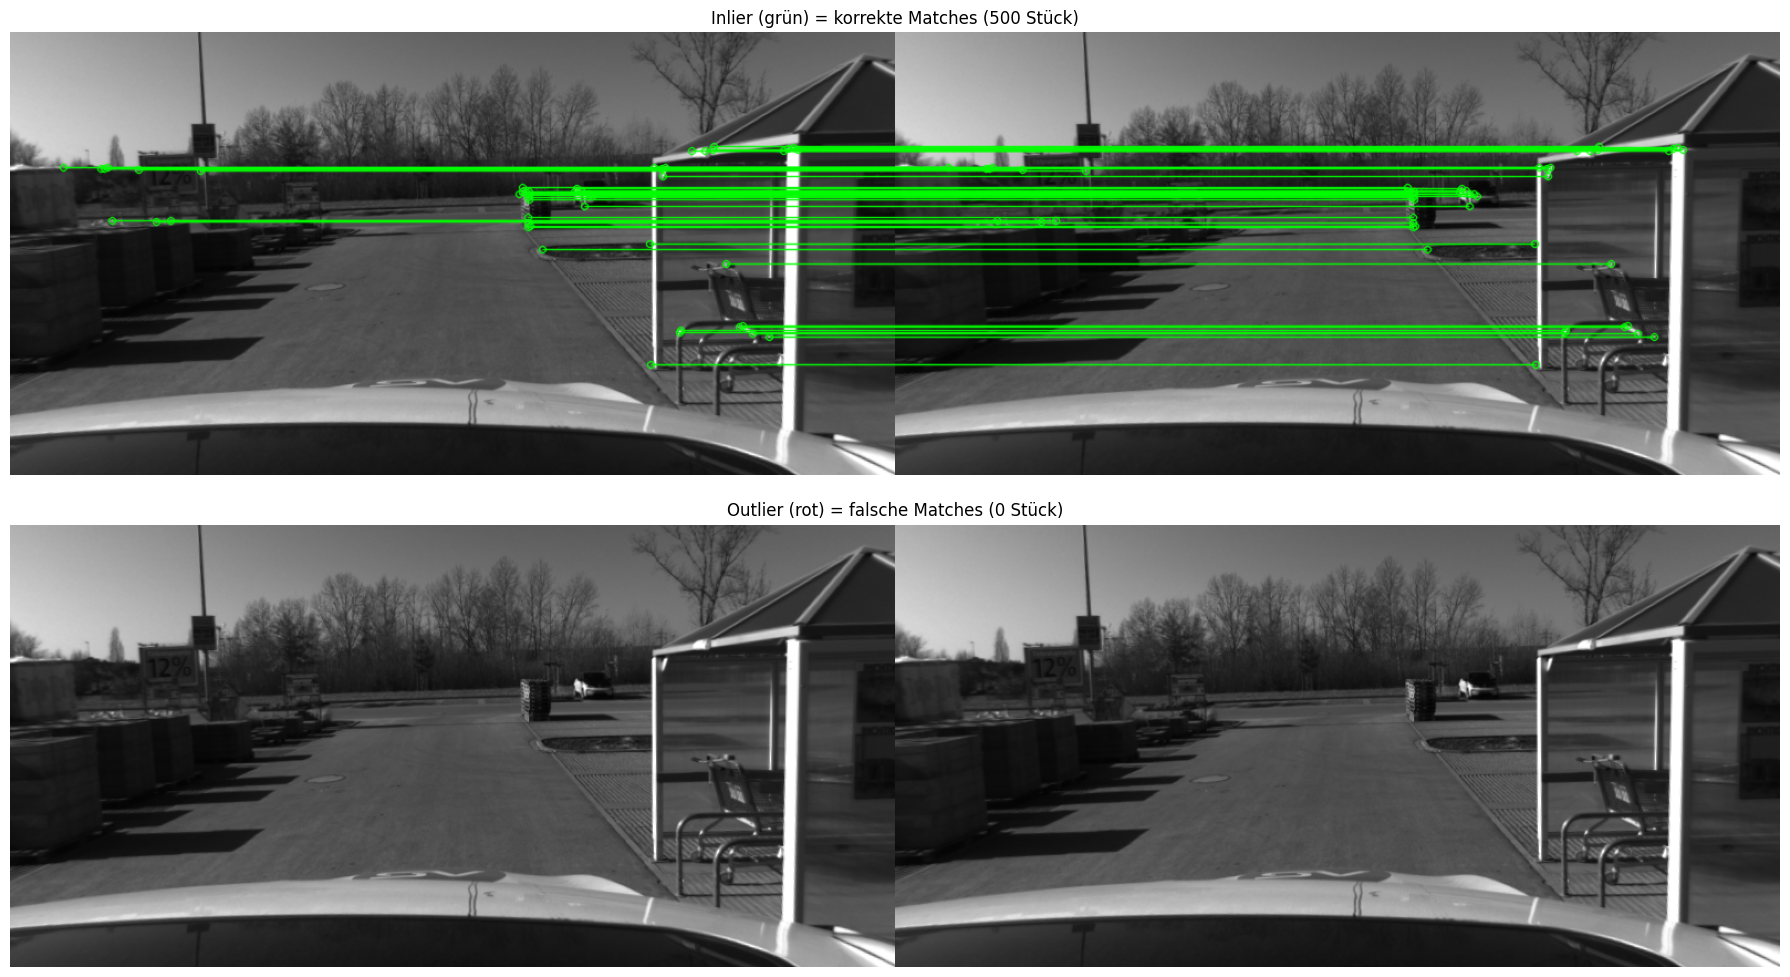

In [28]:
# Koordinaten extrahieren — maximal 500 Punkte (OpenCV 4.13 Bug fix)
max_punkte = 500
matches_begrenzt = gute_matches[:max_punkte]

punkte1 = np.float32([kp1[m.queryIdx].pt for m in matches_begrenzt])
punkte2 = np.float32([kp2[m.trainIdx].pt for m in matches_begrenzt])

print(f"Anzahl Punkte für RANSAC: {len(punkte1)}")

# RANSAC mit Keyword-Argumenten
F, maske = cv2.findFundamentalMat(
    punkte1, punkte2,
    method=cv2.FM_RANSAC,
    ransacReprojThreshold=3.0,
    confidence=0.99
)

if maske is None:
    print("RANSAC fehlgeschlagen")
    maske = np.ones(len(matches_begrenzt), dtype=bool)
else:
    maske = maske.ravel().astype(bool)

inlier_matches  = [m for m, flag in zip(matches_begrenzt, maske) if flag]
outlier_matches = [m for m, flag in zip(matches_begrenzt, maske) if not flag]

print(f"Vor RANSAC:  {len(matches_begrenzt)} Matches")
print(f"Inlier:      {len(inlier_matches)}  ✓ (korrekte Matches)")
print(f"Outlier:     {len(outlier_matches)}  ✗ (falsche Matches, verworfen)")

bild_inlier = cv2.drawMatches(frame1_rgb, kp1, frame2_rgb, kp2,
                               inlier_matches[:50], None,
                               matchColor=(0, 255, 0),
                               flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

bild_outlier = cv2.drawMatches(frame1_rgb, kp1, frame2_rgb, kp2,
                                outlier_matches[:50], None,
                                matchColor=(255, 0, 0),
                                flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

fig, axes = plt.subplots(2, 1, figsize=(18, 10))
axes[0].imshow(bild_inlier)
axes[0].set_title(f"Inlier (grün) = korrekte Matches ({len(inlier_matches)} Stück)")
axes[0].axis('off')
axes[1].imshow(bild_outlier)
axes[1].set_title(f"Outlier (rot) = falsche Matches ({len(outlier_matches)} Stück)")
axes[1].axis('off')
plt.tight_layout()
plt.show()

---
## Schritt 4: Essential Matrix berechnen

Die Essential Matrix **E** beschreibt die geometrische Beziehung zwischen zwei Kameraansichten:

$$E = [t]_{\times} R$$

Sie enthält sowohl die **Rotation R** als auch die **Translation t** — aber noch zusammengepackt.
Dafür brauchen wir die **Kamera-Kalibrierungsmatrix K** (innere Parameter der Kamera).

In [29]:
# Kamera-Kalibrierung (Standardwerte für das Dataset)
# K enthält: Brennweite (fx, fy) und Bildmittelpunkt (cx, cy)
h, w = frame1.shape[:2]
fx = w * 0.8   # geschätzte Brennweite
fy = w * 0.8
cx = w / 2
cy = h / 2

K = np.array([[fx,  0, cx],
              [ 0, fy, cy],
              [ 0,  0,  1]], dtype=np.float64)

print("Kamera-Matrix K:")
print(f"  fx={fx:.1f}  fy={fy:.1f}  (Brennweite in Pixel)")
print(f"  cx={cx:.1f}  cy={cy:.1f}  (Bildmitte)")
print()

# Nur Inlier-Punkte verwenden
p1 = np.float32([kp1[m.queryIdx].pt for m in inlier_matches])
p2 = np.float32([kp2[m.trainIdx].pt for m in inlier_matches])

# Essential Matrix berechnen
E, maske_e = cv2.findEssentialMat(p1, p2, K,
                                   method=cv2.RANSAC,
                                   prob=0.999,
                                   threshold=1.0)

print("Essential Matrix E:")
print(E.round(3))
print()
print("Die Essential Matrix enthält R und t zusammengepackt.")
print("Im nächsten Schritt entpacken wir sie.")

Kamera-Matrix K:
  fx=640.0  fy=640.0  (Brennweite in Pixel)
  cx=400.0  cy=200.0  (Bildmitte)

Essential Matrix E:
[[-0.    -0.428 -0.019]
 [ 0.428 -0.    -0.563]
 [ 0.019  0.563 -0.   ]]

Die Essential Matrix enthält R und t zusammengepackt.
Im nächsten Schritt entpacken wir sie.


---
## Schritt 5: Bewegung bestimmen (R und t)

Die Essential Matrix wird zerlegt in:
- **R** = Rotationsmatrix → wie hat sich die Kamera **gedreht**?
- **t** = Translationsvektor → in welche **Richtung** hat sie sich bewegt?

Aus R kann man die Winkel (Grad) ablesen, aus t die Richtung der Bewegung.

In [30]:
# R und t aus Essential Matrix extrahieren
_, R, t, maske_pose = cv2.recoverPose(E, p1, p2, K)

# Rotationswinkel aus R berechnen
sy = np.sqrt(R[0,0]**2 + R[1,0]**2)
pitch = np.degrees(np.arctan2(-R[2,0], sy))   # Nicken  (hoch/runter)
yaw   = np.degrees(np.arctan2(R[1,0], R[0,0])) # Gieren  (links/rechts)
roll  = np.degrees(np.arctan2(R[2,1], R[2,2])) # Rollen  (kippen)

print("=" * 45)
print("KAMERABEWEGUNG – ERGEBNIS")
print("=" * 45)
print()
print("ROTATION (wie hat sich die Kamera gedreht?):")
print(f"  Nicken  (hoch/runter):    {pitch:+.3f}°")
print(f"  Gieren  (links/rechts):   {yaw:+.3f}°")
print(f"  Rollen  (kippen):         {roll:+.3f}°")
print()
print("TRANSLATION (in welche Richtung hat sie sich bewegt?):")
print(f"  X (links/rechts):  {t[0][0]:+.3f}")
print(f"  Y (hoch/runter):   {t[1][0]:+.3f}")
print(f"  Z (vor/zurück):    {t[2][0]:+.3f}")
print()
print("Hinweis: t ist einheitenlos (kein Maßstab bei Mono-Kamera)")
print(f"         Richtung der Bewegung ist aber korrekt")

KAMERABEWEGUNG – ERGEBNIS

ROTATION (wie hat sich die Kamera gedreht?):
  Nicken  (hoch/runter):    +0.000°
  Gieren  (links/rechts):   +0.000°
  Rollen  (kippen):         -0.000°

TRANSLATION (in welche Richtung hat sie sich bewegt?):
  X (links/rechts):  -0.796
  Y (hoch/runter):   +0.027
  Z (vor/zurück):    -0.605

Hinweis: t ist einheitenlos (kein Maßstab bei Mono-Kamera)
         Richtung der Bewegung ist aber korrekt


---
## Bonus: Trajektorie über mehrere Frames

Wenn wir die Bewegung über viele Frames aufsummieren, entsteht der **zurückgelegte Weg der Kamera**.

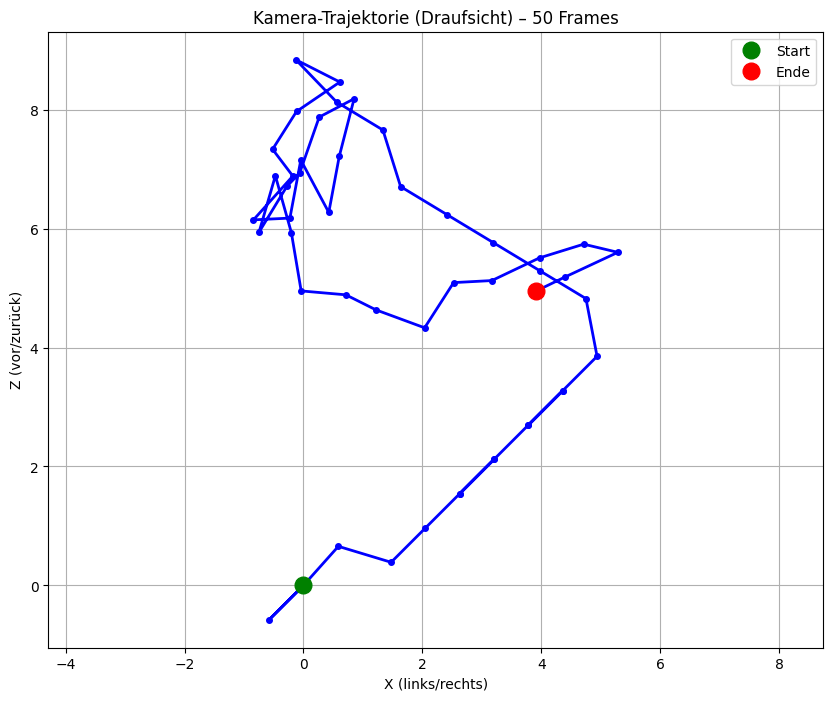

Trajektorie berechnet aus 50 Frames
Start: (0.00, 0.00)
Ende:  (3.92, 4.95)


In [31]:
# Trajektorie über die ersten 50 Frames berechnen
anzahl_frames = min(50, len(bilder) - 1)

position = np.zeros(3)          # Startposition (0, 0, 0)
rotation_gesamt = np.eye(3)     # Keine Rotation am Anfang
trajektorie = [position.copy()]

prev = cv2.cvtColor(cv2.imread(os.path.join(CAM0_ORDNER, bilder[0])), cv2.COLOR_BGR2GRAY)

for i in range(1, anzahl_frames):
    curr = cv2.cvtColor(cv2.imread(os.path.join(CAM0_ORDNER, bilder[i])), cv2.COLOR_BGR2GRAY)
    
    kp_a, desc_a = orb.detectAndCompute(prev, None)
    kp_b, desc_b = orb.detectAndCompute(curr, None)
    
    if desc_a is None or desc_b is None:
        continue
    
    matches = matcher.knnMatch(desc_a, desc_b, k=2)
    gut = [m for m, n in matches if m.distance < 0.75 * n.distance]
    
    if len(gut) < 8:
        continue
    
    pa = np.float32([kp_a[m.queryIdx].pt for m in gut])
    pb = np.float32([kp_b[m.trainIdx].pt for m in gut])
    
    E_i, _ = cv2.findEssentialMat(pa, pb, K, method=cv2.RANSAC, prob=0.999, threshold=1.0)
    if E_i is None:
        continue
    
    _, R_i, t_i, _ = cv2.recoverPose(E_i, pa, pb, K)
    
    # Position aufsummieren
    position = position + rotation_gesamt @ t_i.ravel()
    rotation_gesamt = R_i @ rotation_gesamt
    trajektorie.append(position.copy())
    
    prev = curr

trajektorie = np.array(trajektorie)

# Draufsicht der Trajektorie (X-Z Ebene)
plt.figure(figsize=(10, 8))
plt.plot(trajektorie[:, 0], trajektorie[:, 2], 'b-o', markersize=4, linewidth=2)
plt.plot(trajektorie[0, 0], trajektorie[0, 2], 'go', markersize=12, label='Start')
plt.plot(trajektorie[-1, 0], trajektorie[-1, 2], 'ro', markersize=12, label='Ende')
plt.xlabel('X (links/rechts)')
plt.ylabel('Z (vor/zurück)')
plt.title(f'Kamera-Trajektorie (Draufsicht) – {len(trajektorie)} Frames')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

print(f"Trajektorie berechnet aus {len(trajektorie)} Frames")
print(f"Start: ({trajektorie[0,0]:.2f}, {trajektorie[0,2]:.2f})")
print(f"Ende:  ({trajektorie[-1,0]:.2f}, {trajektorie[-1,2]:.2f})")

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

# Bilder direkt laden
CAM0_ORDNER = "../cam0"
alle_bilder = sorted([f for f in os.listdir(CAM0_ORDNER) if f.endswith('.png')])
print(f"Anzahl Frames: {len(alle_bilder)}")

# ── 1. Startpunkt ─────────────────────────────────────────────────────────
start_kp = max(kp1, key=lambda k: k.response)
punkt = np.array([[start_kp.pt]], dtype=np.float32)
print(f"Startpunkt: ({int(punkt[0,0,0])}, {int(punkt[0,0,1])})")

# ── 2. Feature über alle Frames verfolgen ────────────────────────────────
ANZAHL_FRAMES = len(alle_bilder)
spur_x = [float(punkt[0, 0, 0])]
spur_y = [float(punkt[0, 0, 1])]
frames_rgb = []

lk_params = dict(winSize=(41, 41), maxLevel=4,
                 criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 50, 0.001))

prev_grau = cv2.cvtColor(cv2.imread(os.path.join(CAM0_ORDNER, alle_bilder[0])), cv2.COLOR_BGR2GRAY)
frames_rgb.append(cv2.cvtColor(cv2.imread(os.path.join(CAM0_ORDNER, alle_bilder[0])), cv2.COLOR_BGR2RGB))

for i in range(1, ANZAHL_FRAMES):
    curr = cv2.imread(os.path.join(CAM0_ORDNER, alle_bilder[i]))
    curr_grau = cv2.cvtColor(curr, cv2.COLOR_BGR2GRAY)
    neuer_punkt, status, _ = cv2.calcOpticalFlowPyrLK(prev_grau, curr_grau, punkt, None, **lk_params)
    h, w = curr_grau.shape
    x_neu, y_neu = neuer_punkt[0, 0]

    if status[0, 0] == 1 and 0 < x_neu < w and 0 < y_neu < h:
        punkt = neuer_punkt
        spur_x.append(float(x_neu))
        spur_y.append(float(y_neu))
    else:
        neue_kps = cv2.goodFeaturesToTrack(curr_grau, maxCorners=1, qualityLevel=0.3, minDistance=7)
        if neue_kps is not None:
            punkt = neue_kps
            spur_x.append(float(punkt[0, 0, 0]))
            spur_y.append(float(punkt[0, 0, 1]))
        else:
            spur_x.append(spur_x[-1])
            spur_y.append(spur_y[-1])

    frames_rgb.append(cv2.cvtColor(curr, cv2.COLOR_BGR2RGB))
    prev_grau = curr_grau
    if i % 50 == 0:
        print(f"  {i}/{ANZAHL_FRAMES} verarbeitet...")

print(f"Fertig! {len(spur_x)} Frames verfolgt")

# ── 3. Animation als GIF speichern ───────────────────────────────────────
fig, (ax_bild, ax_plot) = plt.subplots(2, 1, figsize=(8, 8))
fig.suptitle(f"Feature Tracking über {ANZAHL_FRAMES} Frames", fontsize=13)

ax_bild.axis('off')
im = ax_bild.imshow(frames_rgb[0])
punkt_marker, = ax_bild.plot([], [], 'ro', markersize=10)
spur_linie,   = ax_bild.plot([], [], 'r-', linewidth=2, alpha=0.7)
frame_text = ax_bild.text(10, 20, '', color='yellow', fontsize=11, fontweight='bold')

ax_plot.set_xlim(min(spur_x) - 20, max(spur_x) + 20)
ax_plot.set_ylim(max(spur_y) + 20, min(spur_y) - 20)
ax_plot.set_xlabel('X (Pixel)')
ax_plot.set_ylabel('Y (Pixel)')
ax_plot.set_title('Wanderung des Features')
ax_plot.grid(True)
plot_spur,    = ax_plot.plot([], [], 'b-', linewidth=1.5)
plot_aktuell, = ax_plot.plot([], [], 'ro', markersize=8, label='Aktuell')
ax_plot.plot(spur_x[0], spur_y[0], 'go', markersize=10, label='Start')
ax_plot.legend()

def update(i):
    im.set_data(frames_rgb[i])
    punkt_marker.set_data([spur_x[i]], [spur_y[i]])
    spur_linie.set_data(spur_x[:i+1], spur_y[:i+1])
    frame_text.set_text(f'Frame {i+1} / {ANZAHL_FRAMES}')
    plot_spur.set_data(spur_x[:i+1], spur_y[:i+1])
    plot_aktuell.set_data([spur_x[i]], [spur_y[i]])
    return im, punkt_marker, spur_linie, frame_text, plot_spur, plot_aktuell

ani = FuncAnimation(fig, update, frames=ANZAHL_FRAMES, interval=50, blit=True)

# Als GIF speichern
gif_pfad = "../recording/feature_tracking.gif"
os.makedirs("../recording", exist_ok=True)
print("Speichere GIF... (kann etwas dauern)")
ani.save(gif_pfad, writer=PillowWriter(fps=20))
plt.close()
print(f"GIF gespeichert: {gif_pfad}")

# GIF anzeigen
Image(gif_pfad)

Anzahl Frames: 275
Startpunkt: (519, 146)
  50/275 verarbeitet...
  100/275 verarbeitet...
  150/275 verarbeitet...
  200/275 verarbeitet...
  250/275 verarbeitet...
Fertig! 275 Frames verfolgt
Speichere GIF... (kann etwas dauern)


---
## Zusammenfassung

```
Schritt 1: ORB Features extrahieren   → WO sind Punkte in beiden Frames?
Schritt 2: Feature Matching           → Welche Punkte sind dieselben?
Schritt 3: RANSAC                     → Falsche Matches rauswerfen
Schritt 4: Essential Matrix           → Geometrie zwischen den Frames
Schritt 5: R und t bestimmen          → Wie hat sich die Kamera bewegt?
Bonus:     Trajektorie                → Der zurückgelegte Weg
```

**Output:** R (Rotation) + t (Translation) → geht weiter als Input in **2.1 Lokales Mapping**